<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Expt_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Tue May 12 15:27:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os
import matplotlib.pyplot as plt

In [3]:
# Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
train_dir = os.path.join(path, 'chest_xray', 'train')
test_dir = os.path.join(path, 'chest_xray', 'test')

# Setup Generators (Simplified for speed)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255) # Removed augmentation for speed
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_gen = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

def fast_train(model, name):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    print(f"--- Fast Training {name} ---")
    # Training for 3 epochs with limited validation steps to save time
    history = model.fit(train_gen, epochs=3, validation_data=test_gen, validation_steps=10)
    tf.keras.backend.clear_session() # Frees RAM immediately
    return history

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [4]:
alexnet = models.Sequential([
    layers.Conv2D(48, 11, strides=4, activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(3, strides=2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
alexnet_history = fast_train(alexnet, "AlexNet")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Fast Training AlexNet ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 530ms/step - accuracy: 0.8790 - loss: 0.3409 - val_accuracy: 0.8125 - val_loss: 0.4159
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 352ms/step - accuracy: 0.9525 - loss: 0.1214 - val_accuracy: 0.6594 - val_loss: 1.1166
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 364ms/step - accuracy: 0.9580 - loss: 0.1126 - val_accuracy: 0.7812 - val_loss: 0.5018


In [5]:
vgg16_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg16_base.trainable = False
vgg16 = models.Sequential([vgg16_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
vgg16_history = fast_train(vgg16, "VGG16")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Fast Training VGG16 ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 415ms/step - accuracy: 0.7452 - loss: 0.4949 - val_accuracy: 0.6687 - val_loss: 0.5254
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 411ms/step - accuracy: 0.8092 - loss: 0.3806 - val_accuracy: 0.6625 - val_loss: 0.5051
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 410ms/step - accuracy: 0.8704 - loss: 0.3207 - val_accuracy: 0.7406 - val_loss: 0.4629


In [6]:
vgg19_base = tf.keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg19_base.trainable = False
vgg19 = models.Sequential([vgg19_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
vgg19_history = fast_train(vgg19, "VGG19")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Fast Training VGG19 ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 438ms/step - accuracy: 0.7506 - loss: 0.4739 - val_accuracy: 0.6500 - val_loss: 0.5579
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 418ms/step - accuracy: 0.8248 - loss: 0.3776 - val_accuracy: 0.7000 - val_loss: 0.4953
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 417ms/step - accuracy: 0.8627 - loss: 0.3313 - val_accuracy: 0.7406 - val_loss: 0.4777


In [7]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

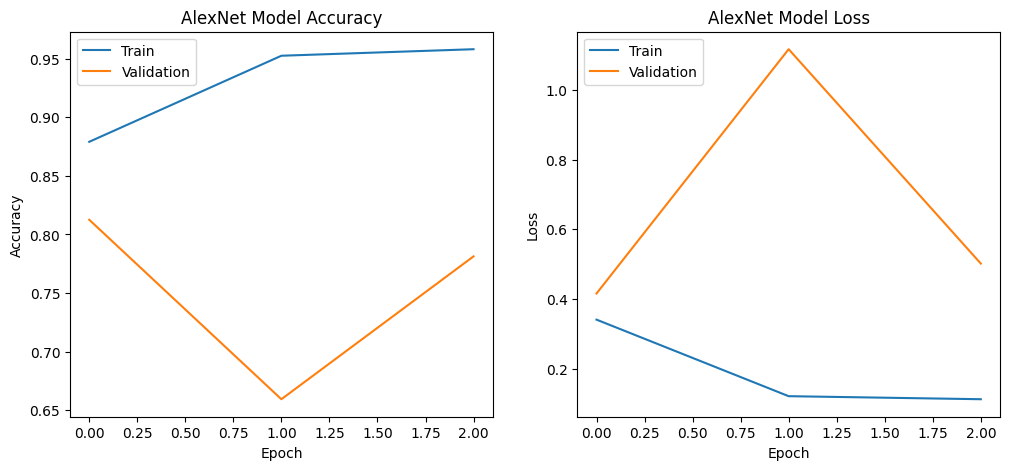

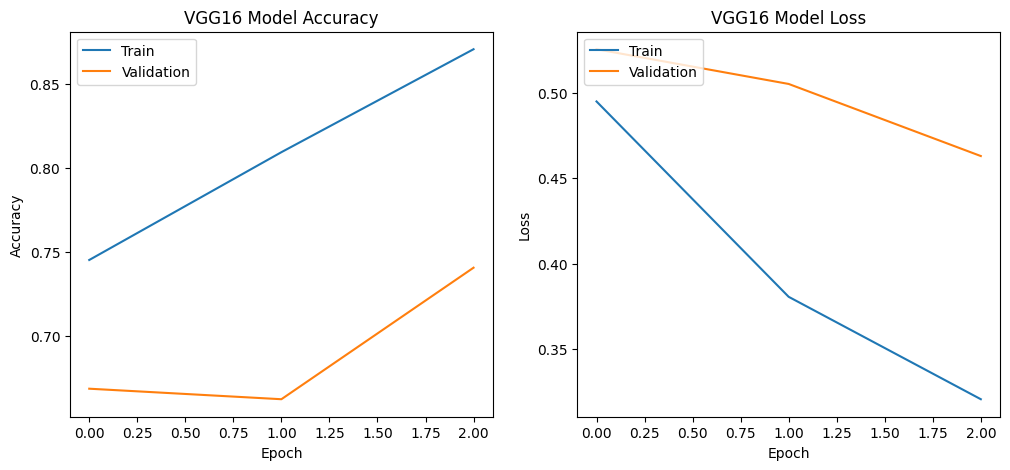

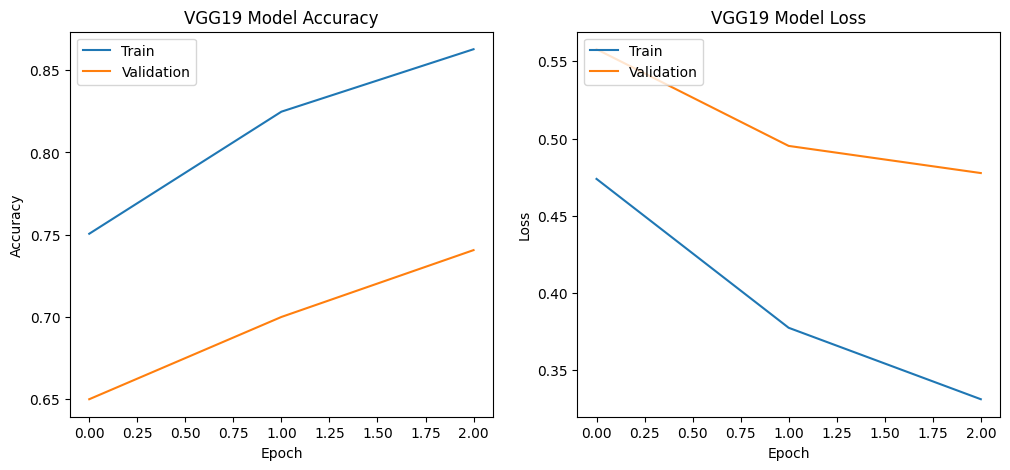

In [8]:
plot_history(alexnet_history, "AlexNet")
plot_history(vgg16_history, "VGG16")
plot_history(vgg19_history, "VGG19")